# Lista 5 — Zadanie 1: Eksploracja zbioru PolEmo2.0-IN (10 pkt)

Cel: załadować zbiór `allegro/klej-polemo2-in`, sprawdzić podstawowe statystyki i **wykluczyć klasę ambiguous**.

> Zalecane środowisko: Google Colab z GPU (Runtime → Change runtime type → T4 GPU).

In [2]:
import sys

!{sys.executable} -m pip install -q datasets pandas matplotlib seaborn

In [3]:
import sys
from pathlib import Path

# Dodajemy folder task-5 do ścieżki, żeby importować moduł common
TASK5_DIR = Path("..").resolve()
if str(TASK5_DIR) not in sys.path:
    sys.path.insert(0, str(TASK5_DIR))

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from common.labels import AMBIGUOUS_LABEL, DATASET_LABEL_TO_CLASS, map_dataset_label
from common.data import load_polemo_test

## Krok 1: Załadowanie surowego zbioru (split test)

In [4]:
raw_dataset = load_dataset("allegro/klej-polemo2-in", split="test")

print(f"Liczba próbek w split test: {len(raw_dataset)}")
print(f"\nPrzykład pierwszej recenzji:")
print(f"  Tekst:  {raw_dataset[0]['sentence']}")
print(f"  Etykieta: {raw_dataset[0]['target']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.01k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/4.88M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/602k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/591k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5783 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/723 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/722 [00:00<?, ? examples/s]

Liczba próbek w split test: 722

Przykład pierwszej recenzji:
  Tekst:  Leczyła m się u niej parę lat i nic mi nie pomogła , a jak zmieniła m lekarza po krótkim czasie zobaczyła m już poprawę a w tej chwili jestem już bez leków 6 lat i jest wszystko dobrze . Dr Ciborska leczyła mnie na depresję a potem przez dr Kopystecką miała m rozpoznany zespół maniakalno depresyjny i odtąd zmianę leków i przede wszystkim wysłuchała mnie z zaagażowaniem a nie jak dr Ciborska aby mnie zbyć
  Etykieta: __label__meta_minus_m


## Krok 2: Filtrowanie — usuwamy klasę ambiguous

In [5]:
examples = load_polemo_test()
df = pd.DataFrame(examples)

removed = len(raw_dataset) - len(df)
print(f"Usunięto {removed} próbek z klasą ambiguous ({AMBIGUOUS_LABEL})")
print(f"Pozostało {len(df)} próbek do klasyfikacji")

Usunięto 108 próbek z klasą ambiguous (__label__meta_amb)
Pozostało 614 próbek do klasyfikacji


## Krok 3: Rozkład klas (zrównoważenie)

Liczność klas:
class
minus      300
neutral    117
plus       197
Name: count, dtype: int64

Proporcje (%):
class
minus      48.9
neutral    19.1
plus       32.1
Name: count, dtype: float64


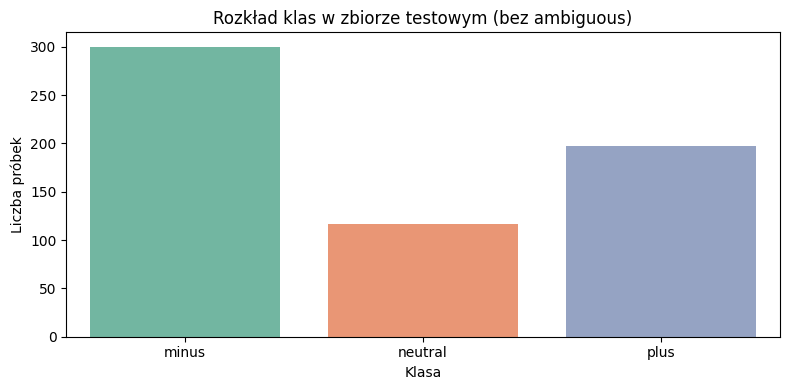

In [6]:
class_counts = df["class"].value_counts().sort_index()
print("Liczność klas:")
print(class_counts)
print(f"\nProporcje (%):")
print((class_counts / len(df) * 100).round(1))

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="Set2", legend=False)
plt.title("Rozkład klas w zbiorze testowym (bez ambiguous)")
plt.xlabel("Klasa")
plt.ylabel("Liczba próbek")
plt.tight_layout()
plt.show()

## Krok 4: Długość tekstów

Statystyki długości tekstów (znaki):
count     614.0
mean      759.4
std       403.0
min        29.0
25%       452.2
50%       694.0
75%       937.8
max      2469.0
Name: char_len, dtype: float64

Statystyki długości tekstów (słowa):
count    614.0
mean     132.6
std       71.7
min        6.0
25%       82.0
50%      120.0
75%      162.0
max      440.0
Name: word_len, dtype: float64


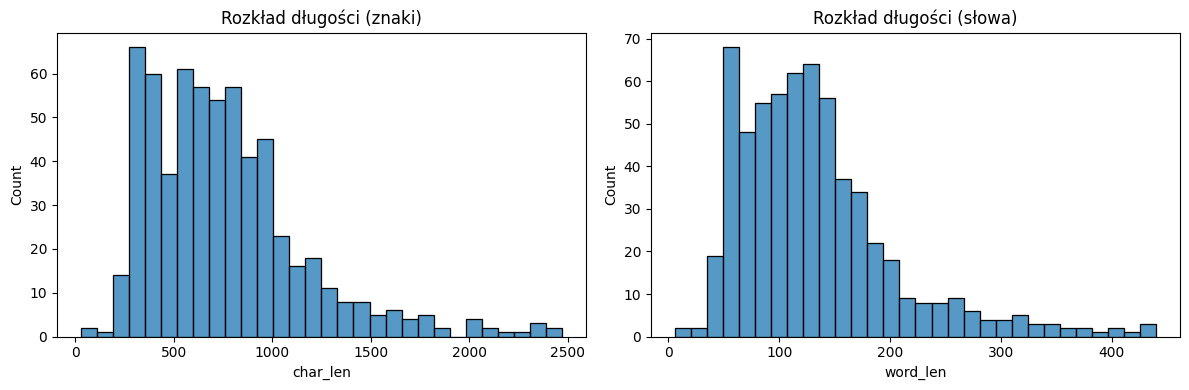

In [7]:
df["char_len"] = df["sentence"].str.len()
df["word_len"] = df["sentence"].str.split().str.len()

print("Statystyki długości tekstów (znaki):")
print(df["char_len"].describe().round(1))
print("\nStatystyki długości tekstów (słowa):")
print(df["word_len"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["char_len"], bins=30, ax=axes[0])
axes[0].set_title("Rozkład długości (znaki)")
sns.histplot(df["word_len"], bins=30, ax=axes[1])
axes[1].set_title("Rozkład długości (słowa)")
plt.tight_layout()
plt.show()

## Krok 5: Przykładowe recenzje z każdej klasy

In [8]:
for class_name in sorted(df["class"].unique()):
    sample = df[df["class"] == class_name].iloc[0]
    print(f"\n--- Klasa: {class_name} (etykieta: {sample['target']}) ---")
    print(sample["sentence"][:300] + ("..." if len(sample["sentence"]) > 300 else ""))


--- Klasa: minus (etykieta: __label__meta_minus_m) ---
Leczyła m się u niej parę lat i nic mi nie pomogła , a jak zmieniła m lekarza po krótkim czasie zobaczyła m już poprawę a w tej chwili jestem już bez leków 6 lat i jest wszystko dobrze . Dr Ciborska leczyła mnie na depresję a potem przez dr Kopystecką miała m rozpoznany zespół maniakalno depresyjny ...

--- Klasa: neutral (etykieta: __label__meta_zero) ---
„ Cukrzyca , to choroba , którą już pod koniec XX wieku uważano za epidemię . Obecnie już wiemy , że to także epidemia XXI wieku . Mówiąc o chorobowości w Polsce , to na podstawie danych NFZ , które są najbardziej wiarygodne , wiemy , że wynosi ona 5 , 2 proc . naszej populacji ” – mówiła na poniedz...

--- Klasa: plus (etykieta: __label__meta_plus_m) ---
Konkretna , Wszystkie badania robi na miejscu od razu przy wizycie . Zawsze wychodzi się z gabinetu z postawioną diagnozą . Potrafi pomóc juz na pierwszej wizycie . Chodze do niej juz od kilku lat . Prowadziła ciązę kilku moim 

## Podsumowanie (do raportu)

- Zbiór testowy zawiera recenzje polskie z domen medycyny i hotelarstwa.
- Po usunięciu klasy **ambiguous** zostają 3 klasy: **minus**, **neutral**, **plus**.
- Sprawdź powyższe wykresy: czy klasy są zrównoważone i jak długie są teksty.
- Te dane (`load_polemo_test()`) będą używane we wszystkich kolejnych zadaniach.